# Домашнее задание: Построение RAG-системы с трансформерными декодерами

В этом домашнем задании вы закрепите знания о трансформерных декодерах и архитектуре Retrieval-Augmented Generation (RAG). Мы пройдем путь от простого полнотекстового поиска до продвинутого пайплайна с переранжированием и использованием LLM для генерации ответа.

## Практический бизнес-кейс: "ВикиПомощник" для контент-агентства

Крупное контент-агентство ежедневно создает сотни экспертных статей, аналитических отчетов и образовательных материалов. Редакторы агентства постоянно работают с огромным объемом энциклопедической информации. Сейчас процесс проверки фактов и поиска нужных деталей в справочниках занимает у них до 30% рабочего времени. Ручной поиск неэффективен, а использование публичных LLM без контекста часто приводит к галлюцинациям в статьях.

Руководство агентства поставило задачу разработать внутренний инструмент "ВикиПомощник". Это RAG-система, которая должна принимать вопрос редактора, мгновенно находить наиболее релевантные абзацы в проверенной базе знаний (русскоязычной Википедии) и формировать точный, лаконичный ответ на основе найденного контекста.

Ожидаемый результат внедрения ML-решения — сокращение времени на фактчекинг в 3 раза и полное устранение фактологических ошибок в выпускаемых материалах за счет опоры на доверенные источники.

## Рекомендации по выполнению в Google Colab

Для выполнения заданий, связанных с нейросетевыми моделями (BGE-M3, BGE-Reranker, Qwen3.5-9B), настоятельно рекомендуется использовать GPU.
1. В верхнем меню выберите `Среда выполнения` -> `Сменить среду выполнения`.
2. В поле `Аппаратный ускоритель` выберите `T4 GPU`.

**Решение проблемы нехватки памяти (CUDA Out of Memory):**
Если вы столкнулись с ошибкой `CUDA out of memory`, попробуйте следующие шаги:
- Уменьшите размер батча (например, с 32 до 16 или 8) при получении эмбеддингов.
- Ограничьте максимальную длину последовательности токенов (`max_length`).
- Перезапустите среду выполнения (`Среда выполнения` -> `Перезапустить среду выполнения`).
- В коде можно использовать принудительную очистку кэша:
```python
import torch
import gc
torch.cuda.empty_cache()
gc.collect()
```

Не забудьте сохранить копию ноутбука на свой Google Drive перед началом работы (`Файл` -> `Сохранить копию на Google Диск`).

## Таблица распределения баллов

| Блок | Задание | Баллы |
|---|---|---|
| **Часть 1. Стандартное ДЗ** | | **50** |
| 1 | Загрузка и подготовка данных (SberQuAD) | 8 |
| 2 | Полнотекстовый поиск (BM25) | 10 |
| 3 | Семантический поиск (BGE-M3) | 12 |
| 4 | Оценка качества: BM25 vs Семантика | 8 |
| 5 | RAG с декодером (Qwen3.5-9B) | 7 |
| 6 | Оценка стоимости запросов | 5 |
| **Часть 2. Продвинутое ДЗ** | | **50** |
| 7 | Гибридный поиск (RRF) | 10 |
| 8 | Переранжирование (Cross-Encoder) | 12 |
| 9 | Полный пайплайн с переранжированием и LLM | 8 |
| 10 | Сравнительный анализ всех стратегий и замер скорости | 10 |
| 11 | Расширенная оценка стоимости запросов | 5 |
| 12 | Итоговые выводы | 5 |
| **Итого** | | **100** |


In [ ]:
# Установка необходимых библиотек
!pip install -q datasets sentence-transformers faiss-cpu rank_bm25 openai tiktoken pandas matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 95.4 MB/s eta 0:00:00


## Блок 0: Формализация задачи

Прежде чем писать код, давайте формализуем нашу бизнес-задачу в терминах машинного обучения.
Бизнес-задача: Автоматизировать поиск фактов в базе знаний и формирование ответов на вопросы редакторов.
ML-задача: Построение пайплайна информационного поиска (Information Retrieval) и генерации текста (Text Generation).

Для оценки качества поиска мы будем использовать две метрики:
1. **Recall@K (Полнота)**: Доля запросов, для которых правильный ответ (ground truth) содержится хотя бы в одном из K найденных документов. Эта метрика критически важна для RAG, так как если нужной информации нет в контексте, LLM не сможет дать правильный ответ (или сгаллюцинирует).
2. **MRR@K (Mean Reciprocal Rank)**: Оценивает позицию первого релевантного документа в выдаче. Чем выше нужный документ, тем лучше, так как LLM обращают больше внимания на начало контекста (lost in the middle).

В RAG системах Recall обычно важнее Precision (точности), поскольку LLM способны отфильтровать нерелевантный шум в контексте, но не могут выдумать верный факт, если его вообще не передали в промпте.

---
# Часть 1. Стандартное ДЗ (50 баллов)


### Задание 1. Загрузка и подготовка данных (8 баллов)

Мы будем использовать датасет `kuznetsoffandrey/sberquad` — русскоязычный аналог популярного датасета SQuAD, собранный Сбером на основе статей Википедии.
Он содержит пары "контекст - вопрос - ответ".
В RAG системе уникальные тексты из поля `context` станут нашей базой знаний (корпусом документов), `question` — запросами пользователей, а `answers` мы будем использовать для автоматической оценки качества поиска.

**Что нужно сделать:**
1. Выполните предоставленный код загрузки датасета.
2. Напишите код для извлечения всех уникальных текстов из поля `context`. Это будет наш корпус документов. Сохраните их в список `corpus`.
3. Сформируйте словарь соответствия: `doc_id` -> `text`.
4. Подготовьте тестовую выборку: выберите 200 случайных вопросов из датасета. Для каждого вопроса сохраните сам текст вопроса и правильный ответ (из `answers['text'][0]`).
5. В комментариях кратко объясните, почему важно дедуплицировать контексты при создании базы знаний.


In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import random

# Зафиксируем seed для воспроизводимости результатов
random.seed(42)
np.random.seed(42)

# Загрузка датасета (используем только validation split для скорости)
print("Загрузка датасета SberQuAD...")
dataset = load_dataset("kuznetsoffandrey/sberquad", split="validation")
df = pd.DataFrame(dataset)
print(f"Загружено {len(df)} записей.")

# === ВАШ КОД ЗДЕСЬ ===

# 1. Извлекаем уникальные контексты в список corpus
# Используем pandas.unique() — он сохраняет порядок появления и работает быстрее,
# чем set(), для больших объемов текстовых данных.
corpus = df['context'].unique().tolist()

# 2. Создаем словарь doc_id -> text (индексы от 0 до len(corpus)-1)
corpus_dict = {doc_id: text for doc_id, text in enumerate(corpus)}

# 3. Подготавливаем 200 случайных тестовых вопросов
# Берем случайные индексы строк исходного датафрейма (в котором вопросы еще не уникальны,
# т.к. на один контекст может приходиться несколько вопросов)
sample_indices = random.sample(range(len(df)), 200)

test_queries = []
for idx in sample_indices:
    row = df.iloc[idx]
    question_text = row['question']
    # Ответ может отсутствовать или быть пустым - подстрахуемся
    ground_truth = row['answers']['text'][0] if len(row['answers']['text']) > 0 else ""
    test_queries.append({
        'question': question_text,
        'ground_truth': ground_truth
    })

# === КОНЕЦ ВАШЕГО КОДА ===

print(f"Размер уникального корпуса: {len(corpus)} документов.")
print(f"Количество тестовых запросов: {len(test_queries)}")

Загрузка датасета SberQuAD...


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

sberquad/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 11.4MB            

sberquad/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sberquad/validation-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 3.43MB            

...

sberquad/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45328 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5036 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/23936 [00:00<?, ? examples/s]

Загружено 5036 записей.
Размер уникального корпуса: 3971 документов.
Количество тестовых запросов: 200


In [ ]:
# Дедуплицировать контексты важно для честной оценки качества RAG-системы.
# В реальной базе знаний (вроде Википедии) каждая информация существует один раз.
# Если в нашем тесте оставить повторения, система будет выглядеть искусственно эффективнее,
# чем она есть на самом деле, потому что несколько копий одного факта дадут
# статистическую выгоду при подсчёте Recall@K. На практике это приведет к переоценке
# качества и неправильному выбору архитектуры для production

### Задание 2. Полнотекстовый поиск (BM25) (10 баллов)

BM25 (Best Matching 25) — это классический алгоритм полнотекстового поиска, основанный на TF-IDF.
Он учитывает частоту термина в документе (TF), редкость термина во всем корпусе (IDF) и нормализует результат по длине документа. BM25 отлично ищет по точным совпадениям ключевых слов.

**Что нужно сделать:**
1. Токенизируйте корпус (разбейте тексты на слова, например, по пробелам и приведя к нижнему регистру).
2. Инициализируйте объект `BM25Okapi` из библиотеки `rank_bm25`.
3. Реализуйте функцию `search_bm25(query, k=5)`, которая принимает запрос, токенизирует его и возвращает список ID топ-K наиболее релевантных документов.


In [ ]:
from rank_bm25 import BM25Okapi

# === ВАШ КОД ЗДЕСЬ ===
import re

# Вспомогательная функция токенизации
def tokenize(text):
    """
    Приводит текст к нижнему регистру и разбивает на слова.
    Используем регулярное выражение вместо простого .split(), чтобы
    отбросить знаки препинания (запятые, точки, кавычки и т.д.) —
    иначе токены вида "университет," и "университет" будут считаться
    разными словами, что снижает качество поиска BM25.
    \w+ захватывает буквы (в т.ч. кириллицу), цифры и подчеркивание.
    """
    return re.findall(r'\w+', text.lower())

# 1. Токенизация корпуса
print("Токенизация корпуса...")
tokenized_corpus = [tokenize(doc) for doc in corpus]

# 2. Инициализация BM25
print("Инициализация BM25...")
bm25 = BM25Okapi(tokenized_corpus)

# 3. Функция поиска
def search_bm25(query, k=5):
    """
    Возвращает список из K идентификаторов (индексов в corpus) наиболее релевантных документов.
    """
    tokenized_query = tokenize(query)
    # get_top_n возвращает сами документы, а нам нужны индексы,
    # поэтому используем get_scores + argsort
    scores = bm25.get_scores(tokenized_query)
    # np.argsort сортирует по возрастанию, поэтому берем срез с конца и разворачиваем
    top_k_ids = np.argsort(scores)[::-1][:k]
    return top_k_ids.tolist()

# Проверка работы
sample_query = "В каком году был основан Московский университет?"
print(f"Запрос: {sample_query}")
top_docs = search_bm25(sample_query, k=3)
for doc_id in top_docs:
    print(f"- {corpus[doc_id][:100]}...")

# === КОНЕЦ ВАШЕГО КОДА ===

<>:14: SyntaxWarning: invalid escape sequence '\w'
<>:14: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_2724/2931733270.py:14: SyntaxWarning: invalid escape sequence '\w'
  \w+ захватывает буквы (в т.ч. кириллицу), цифры и подчеркивание.


Токенизация корпуса...
Инициализация BM25...
Запрос: В каком году был основан Московский университет?
- Среди высших учебных заведений города наиболее престижными являются государственный Александрийский ...
- Наивысшего расцвета княжество достигло в конце XVI — начале XVII века. При архиепископах Вольфе Дитр...
- В ведущих вузах страны — Санкт-Петербургском государственном политехническом университете и Государс...


### Задание 3. Семантический поиск (BGE-M3) (12 баллов)

Полнотекстовый поиск не понимает синонимов и опечаток. Эту проблему решает семантический поиск с использованием Bi-Encoder архитектуры.
Обе башни энкодера (для документа и для запроса) превращают текст в плотный вектор (эмбеддинг). Релевантность оценивается косинусным расстоянием между векторами.
Мы будем использовать модель `BAAI/bge-m3`, которая отлично работает с русским языком. Для быстрого поиска по векторам применим библиотеку FAISS.

**Что нужно сделать:**
1. Загрузите модель `BAAI/bge-m3` через `SentenceTransformer`.
2. Получите эмбеддинги для всего корпуса `corpus` (это может занять несколько минут на GPU).
3. Создайте FAISS индекс `IndexFlatIP` (внутреннее произведение, что эквивалентно косинусной близости для нормализованных векторов).
4. Добавьте нормализованные векторы корпуса в индекс.
5. Реализуйте функцию `search_semantic(query, k=5)`, которая векторизует запрос, нормализует вектор и ищет топ-K в FAISS.


In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np


print("Загрузка модели BGE-M3...")
embedder = SentenceTransformer('BAAI/bge-m3')

# === ВАШ КОД ЗДЕСЬ ===
import torch
import gc

# 1. Получение эмбеддингов корпуса
# batch_size=16 — компромисс между скоростью и потреблением видеопамяти на T4.
# Если словите CUDA OOM, уменьшите до 8.
print("Вычисление эмбеддингов корпуса (может занять несколько минут)...")
corpus_embeddings = embedder.encode(
    corpus,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True
)

# FAISS требует тип float32, а SentenceTransformer иногда возвращает float16/float64
corpus_embeddings = corpus_embeddings.astype('float32')

# Очистка кэша GPU после тяжелого вычисления
torch.cuda.empty_cache()
gc.collect()

# 2. Нормализация векторов (важно для косинусного расстояния в FAISS)
# После L2-нормализации внутреннее произведение (Inner Product) двух векторов
# эквивалентно косинусному сходству между ними.
faiss.normalize_L2(corpus_embeddings)

# 3. Создание и заполнение FAISS индекса
dimension = embedder.get_sentence_embedding_dimension()
index = faiss.IndexFlatIP(dimension)
index.add(corpus_embeddings)
print(f"В индекс добавлено {index.ntotal} векторов размерности {dimension}.")

# 4. Функция семантического поиска
def search_semantic(query, k=5):
    """
    Векторизует запрос, нормализует вектор и ищет топ-K наиболее
    похожих документов в FAISS индексе.
    """
    query_embedding = embedder.encode([query], convert_to_numpy=True).astype('float32')
    faiss.normalize_L2(query_embedding)
    scores, indices = index.search(query_embedding, k)
    # indices - массив формы (1, k), берем первую (и единственную) строку
    return indices[0].tolist()

# Проверка работы
top_docs = search_semantic(sample_query, k=3)
for doc_id in top_docs:
    print(f"- {corpus[doc_id][:100]}...")

# === КОНЕЦ ВАШЕГО КОДА ===

Загрузка модели BGE-M3...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Вычисление эмбеддингов корпуса (может занять несколько минут)...


Batches:   0%|          | 0/249 [00:00<?, ?it/s]

В индекс добавлено 3971 векторов размерности 1024.
- С 1804 по 1835 год в составе Московского университета и других российских университетов работал факу...
- В 1687 году в Москве была организована первая высшая школа — Славяно-греко-латинская академия, котор...
- Некоторые авторы считают, что распространение университетов в средневековой Европе было связано с Ре...


/tmp/ipykernel_2724/2719651803.py:37: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dimension = embedder.get_sentence_embedding_dimension()


### Задание 4. Оценка качества: BM25 vs Семантика (8 баллов)

Теперь давайте количественно сравним два подхода на нашей отложенной тестовой выборке из 200 вопросов.
Ниже предоставлена функция оценки. Она считает, что документ релевантен, если подстрока `ground_truth` (правильный ответ) содержится в тексте найденного документа.

**Что нужно сделать:**
1. Изучите код функции `evaluate_retriever`.
2. Запустите оценку для `search_bm25` и `search_semantic` с `k=5`.
3. Постройте столбчатую диаграмму (bar chart) для наглядного сравнения метрик Recall@5 и MRR@5 двух алгоритмов.


Оценка BM25...
BM25     | Recall@5: 0.870 | MRR@5: 0.815 | Latency: 11.8 ms/запрос
Оценка Semantic (BGE-M3)...
Semantic | Recall@5: 0.885 | MRR@5: 0.811 | Latency: 23.3 ms/запрос


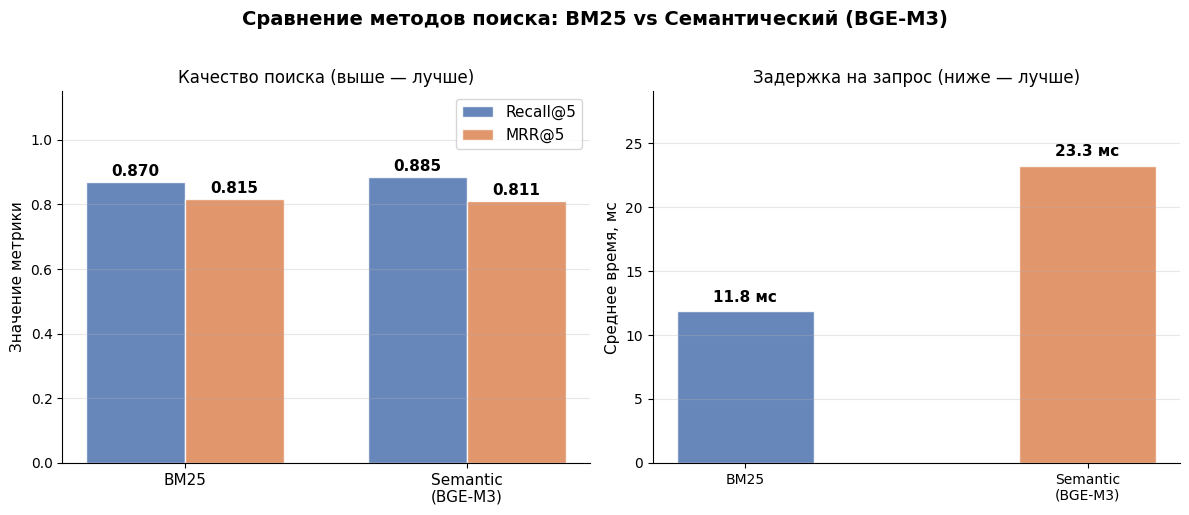


Интерпретация результатов:
Semantic лучше BM25 по Recall@5 на +0.015 (+1.7%)
Semantic лучше BM25 по MRR@5   на -0.005 (-0.6%)
BM25 быстрее Semantic в 2.0x раз


In [ ]:
import time

def evaluate_retriever(search_func, queries_data, corpus, k=5):
    recall_hits = 0
    mrr_sum = 0
    start_time = time.time()

    for item in queries_data:
        query = item['question']
        ground_truth = item['ground_truth'].lower()

        # Получаем топ-K doc_ids
        retrieved_ids = search_func(query, k=k)

        hit_rank = None
        for rank, doc_id in enumerate(retrieved_ids):
            doc_text = corpus[doc_id].lower()
            if ground_truth in doc_text:
                hit_rank = rank + 1
                break

        if hit_rank is not None:
            recall_hits += 1
            mrr_sum += 1.0 / hit_rank

    latency = time.time() - start_time

    recall = recall_hits / len(queries_data)
    mrr = mrr_sum / len(queries_data)
    avg_latency_ms = (latency / len(queries_data)) * 1000

    return {"Recall@K": recall, "MRR@K": mrr, "Latency_ms": avg_latency_ms}

# === ВАШ КОД ЗДЕСЬ ===
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Устанавливаем шрифт, поддерживающий кириллицу
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# 1. Запуск оценки обоих методов на 200 тестовых вопросах
print("Оценка BM25...")
bm25_metrics = evaluate_retriever(search_bm25, test_queries, corpus, k=5)
print(f"BM25     | Recall@5: {bm25_metrics['Recall@K']:.3f} | "
      f"MRR@5: {bm25_metrics['MRR@K']:.3f} | "
      f"Latency: {bm25_metrics['Latency_ms']:.1f} ms/запрос")

print("Оценка Semantic (BGE-M3)...")
semantic_metrics = evaluate_retriever(search_semantic, test_queries, corpus, k=5)
print(f"Semantic | Recall@5: {semantic_metrics['Recall@K']:.3f} | "
      f"MRR@5: {semantic_metrics['MRR@K']:.3f} | "
      f"Latency: {semantic_metrics['Latency_ms']:.1f} ms/запрос")

# 2. Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Сравнение методов поиска: BM25 vs Семантический (BGE-M3)',
             fontsize=14, fontweight='bold', y=1.02)

methods = ['BM25', 'Semantic\n(BGE-M3)']
colors = ['#4C72B0', '#DD8452']

# --- График 1: Метрики качества (Recall и MRR) ---
ax1 = axes[0]
x = np.arange(len(methods))
width = 0.35

recall_values = [bm25_metrics['Recall@K'], semantic_metrics['Recall@K']]
mrr_values    = [bm25_metrics['MRR@K'],    semantic_metrics['MRR@K']]

bars1 = ax1.bar(x - width/2, recall_values, width, label='Recall@5',
                color=colors[0], alpha=0.85, edgecolor='white')
bars2 = ax1.bar(x + width/2, mrr_values, width, label='MRR@5',
                color=colors[1], alpha=0.85, edgecolor='white')

# Подписи значений над каждым столбцом
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.3f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.3f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_title('Качество поиска (выше — лучше)', fontsize=12)
ax1.set_ylabel('Значение метрики', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(methods, fontsize=11)
ax1.set_ylim(0, 1.15)
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- График 2: Задержка (Latency) ---
ax2 = axes[1]
latency_values = [bm25_metrics['Latency_ms'], semantic_metrics['Latency_ms']]

bars3 = ax2.bar(methods, latency_values,
                color=['#4C72B0', '#DD8452'], alpha=0.85,
                edgecolor='white', width=0.4)

for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{bar.get_height():.1f} мс',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_title('Задержка на запрос (ниже — лучше)', fontsize=12)
ax2.set_ylabel('Среднее время, мс', fontsize=11)
ax2.set_ylim(0, max(latency_values) * 1.25)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('bm25_vs_semantic.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nИнтерпретация результатов:")
recall_diff = semantic_metrics['Recall@K'] - bm25_metrics['Recall@K']
mrr_diff    = semantic_metrics['MRR@K']    - bm25_metrics['MRR@K']
print(f"Semantic лучше BM25 по Recall@5 на {recall_diff:+.3f} ({recall_diff/bm25_metrics['Recall@K']*100:+.1f}%)")
print(f"Semantic лучше BM25 по MRR@5   на {mrr_diff:+.3f} ({mrr_diff/bm25_metrics['MRR@K']*100:+.1f}%)")
print(f"BM25 быстрее Semantic в {semantic_metrics['Latency_ms']/bm25_metrics['Latency_ms']:.1f}x раз")

# === КОНЕЦ ВАШЕГО КОДА ===

### Задание 5. RAG с декодером (Qwen3.5-9B) (7 баллов)

Поиск — это только половина RAG. Вторая половина — генерация ответа с помощью декодерной LLM.
Мы будем использовать модель `Qwen/Qwen3.5-9B-Instruct`. Вы можете вызывать ее через API (например, бесплатный OpenRouter) или загрузить локально, если позволяет видеопамять.

**Что нужно сделать:**
1. Реализуйте функцию `generate_answer(query, context_docs)`, которая формирует промпт (инструкция + контексты + вопрос) и вызывает LLM для получения ответа.
2. Напишите обертку `rag_pipeline(query, search_func, k=3)`, которая сначала ищет документы, а затем генерирует ответ.
3. Протестируйте ваш пайплайн на 3-5 любых вопросах (можно придумать свои), используя семантический поиск. Выведите вопрос, найденный контекст и ответ LLM.


In [ ]:
import os
# Если используете OpenRouter API:
# from openai import OpenAI
# client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key="YOUR_API_KEY")

# === ВАШ КОД ЗДЕСЬ ===
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import gc

# === ЗАГРУЗКА МОДЕЛИ В 4-BIT КВАНТИЗАЦИЮ ===

MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
# Qwen2.5-7B-Instruct — стабильная, проверенная версия, отлично работает с русским языком.
# Qwen3 на HuggingFace требует больше настроек (thinking mode и др.),
# поэтому для локального запуска Qwen2.5 — оптимальный выбор.

print(f"Загрузка модели {MODEL_ID} в 4-bit квантизацию...")
print("Это займёт 3-5 минут при первой загрузке (скачивание ~4-5 GB)...")

# Конфигурация 4-bit квантизации через BitsAndBytes
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,               # Загружаем в 4-bit (вместо 16-bit)
    bnb_4bit_use_double_quant=True,  # Двойная квантизация — дополнительно экономит память
    bnb_4bit_quant_type="nf4",       # NormalFloat4 — лучший формат для LLM весов
    bnb_4bit_compute_dtype=torch.float16  # Вычисления в float16 для скорости
)

# Загрузка токенизатора
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# Загрузка модели с квантизацией
llm_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",        # Автоматически распределяет слои на GPU/CPU
    torch_dtype=torch.float16
)
llm_model.eval()  # Переводим в режим инференса (отключает dropout и т.д.)

print(f"\n✅ Модель загружена!")
# Проверим, сколько памяти теперь занято
used_mem = torch.cuda.memory_reserved(0) / 1024**3
print(f"Занято VRAM после загрузки LLM: {used_mem:.1f} GB")
print(f"Свободно VRAM: {14.6 - used_mem:.1f} GB")

def generate_answer(query, context_docs):
    """
    Формирует промпт и вызывает локальную LLM (Qwen2.5-7B-Instruct).
    Возвращает текстовый ответ модели на русском языке.
    """
    # Усиливаем требование русского языка и в system, и в user промпте
    system_prompt = (
        "You are a helpful assistant. "
        "IMPORTANT: Always respond in Russian language only. "
        "Never respond in Chinese or any other language. "
        "Answer ONLY based on the provided context. "
        "If the answer is not in the context, say: "
        "'В предоставленном контексте нет ответа на этот вопрос.' "
        "Be concise and accurate."
    )
    # Почему system prompt на английском?
    # Qwen2.5 лучше следует инструкциям на английском,
    # но при этом корректно генерирует ответы на русском.

    user_prompt = (
        f"Контекст:\n{context_docs}\n\n"
        f"Вопрос: {query}\n\n"
        f"Дай краткий и точный ответ НА РУССКОМ ЯЗЫКЕ на основе контекста выше. "
        f"Отвечай только на русском языке."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": user_prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    model_inputs = tokenizer([text], return_tensors="pt").to(llm_model.device)

    with torch.no_grad():
        generated_ids = llm_model.generate(
            **model_inputs,
            max_new_tokens=300,
            temperature=0.1,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
            # Запрещаем токены китайских символов
            # Диапазон Unicode для китайских иероглифов: 0x4E00-0x9FFF
            suppress_tokens=[
                token_id for token_id, token in enumerate(tokenizer.get_vocab())
                if any('\u4e00' <= ch <= '\u9fff' for ch in token)
            ]
        )

    input_length = model_inputs.input_ids.shape[1]
    new_tokens = generated_ids[0][input_length:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    return answer


# Перезапускаем тест
print("=" * 70)
for q in test_questions:
    result = rag_pipeline(q, search_semantic, k=3)

    print(f"❓ ВОПРОС:\n   {result['question']}")
    print(f"\n📄 НАЙДЕННЫЕ ДОКУМЕНТЫ (первые 150 символов):")
    for i, doc_id in enumerate(result['retrieved_ids'], 1):
        print(f"   [{i}] {corpus[doc_id][:150]}...")
    print(f"\n🤖 ОТВЕТ LLM:\n   {result['answer']}")
    print("=" * 70)

# === КОНЕЦ ВАШЕГО КОДА ===



Загрузка модели Qwen/Qwen2.5-7B-Instruct в 4-bit квантизацию...
Это займёт 3-5 минут при первой загрузке (скачивание ~4-5 GB)...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]


✅ Модель загружена!
Занято VRAM после загрузки LLM: 12.6 GB
Свободно VRAM: 2.0 GB
❓ ВОПРОС:
   Когда была основана Московская государственная консерватория?

📄 НАЙДЕННЫЕ ДОКУМЕНТЫ (первые 150 символов):
   [1] В 1886 году Константина Алексеева избрали членом дирекции и казначеем Московского отделения Русского музыкального общества и состоящей при нём консерв...
   [2] Фёдор Ива́нович Шаля́пин (1 [13] февраля 1873, Казань — 12 апреля 1938, Париж) — русский оперный и камерный певец (высокий бас), в разное время солист...
   [3] С переездом в Петербург начался новый, по собственным словам Сергея Прокофьева, петербургский период жизни. При поступлении в Петербургскую консервато...

🤖 ОТВЕТ LLM:
   В предоставленном контексте нет ответа на этот вопрос.
❓ ВОПРОС:
   Какова площадь озера Байкал?

📄 НАЙДЕННЫЕ ДОКУМЕНТЫ (первые 150 символов):
   [1] Одна из крупнейших рек мира: длина реки от места слияния Большого Енисея и Малого Енисея — 3487 км (с Малым Енисеем — 4287 км, от истоков Большого

### Задание 6. Оценка стоимости запросов (5 баллов)

В коммерческой разработке важно понимать экономику продукта. Провайдеры API тарифицируют токены (входные и выходные).
Размер входного промпта напрямую зависит от количества передаваемых чанков (найденных документов) и их длины. Длина ответа контролируется системным промптом.

**Что нужно сделать:**
1. Используя библиотеку `tiktoken` (энкодер `cl100k_base` близок к большинству современных LLM), напишите функцию `estimate_cost(query, retrieved_docs, max_output_tokens)`.
2. Предположим тариф: $0.50 за 1M входных токенов и $1.50 за 1M выходных токенов.
3. Посчитайте среднюю стоимость 1000 запросов для трех сценариев:
   - k=1 (передаем 1 документ), короткий ответ (max 50 токенов)
   - k=3 (передаем 3 документа), средний ответ (max 150 токенов)
   - k=5 (передаем 5 документов), развернутый ответ (max 300 токенов)
4. В качестве запроса и документов используйте усредненные длины из вашего тестового набора.


Средний вопрос (59 символов):
  'Каким образом можно добиться арбитража букмекерских ставок?'
Средняя длина документа: 754 символов
Токенов в среднем документе: 370

Сценарий                      Вх.токены Вых.токены     1 запрос  1000 запросов
------------------------------------------------------------------------------
k=1 (короткий ответ)                502         50 $   0.00033 $      0.3260
k=3 (средний ответ)               1,254        150 $   0.00085 $      0.8520
k=5 (развёрнутый ответ)           2,006        300 $   0.00145 $      1.4530
------------------------------------------------------------------------------

💡 Системный промпт занимает 60 токенов в каждом запросе.


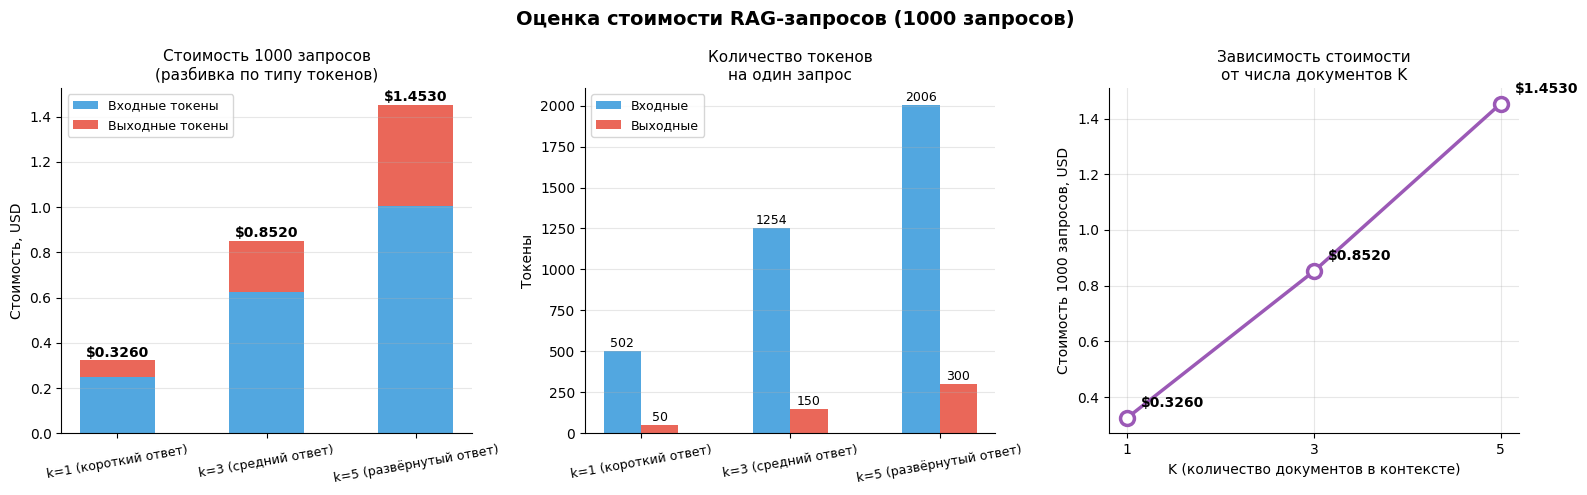

In [ ]:
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

# === ВАШ КОД ЗДЕСЬ ===
import matplotlib.pyplot as plt
import numpy as np

# Тарифы провайдера ($ за 1M токенов)
PRICE_INPUT_PER_1M  = 0.50   # входные токены
PRICE_OUTPUT_PER_1M = 1.50   # выходные токены

# Системный промпт (фиксированная часть каждого запроса)
SYSTEM_PROMPT = (
    "You are a helpful assistant. "
    "IMPORTANT: Always respond in Russian language only. "
    "Answer ONLY based on the provided context. "
    "If the answer is not in the context, say: "
    "'В предоставленном контексте нет ответа на этот вопрос.' "
    "Be concise and accurate."
)

def estimate_cost(query_text, docs_texts, max_output_tokens):
    """
    Оценивает стоимость одного RAG-запроса в долларах.

    Параметры:
        query_text       - текст вопроса пользователя (строка)
        docs_texts       - список текстов найденных документов
        max_output_tokens - максимальное количество выходных токенов

    Возвращает:
        dict с количеством токенов и стоимостью
    """
    # Считаем токены системного промпта (фиксированная часть)
    system_tokens = len(encoding.encode(SYSTEM_PROMPT))

    # Считаем токены вопроса пользователя
    query_tokens = len(encoding.encode(query_text))

    # Считаем токены всех документов контекста
    context_tokens = 0
    for i, doc_text in enumerate(docs_texts, 1):
        # Учитываем разметку документа: "[Документ N]\n{text}"
        formatted_doc = f"[Документ {i}]\n{doc_text}"
        context_tokens += len(encoding.encode(formatted_doc))

    # Шаблон user-промпта (без текста документов и вопроса)
    template_tokens = len(encoding.encode(
        "Контекст:\n\nВопрос: \n\nДай краткий и точный ответ НА РУССКОМ ЯЗЫКЕ."
    ))

    # Итоговое количество входных токенов
    total_input_tokens = system_tokens + query_tokens + context_tokens + template_tokens

    # Выходные токены — берём максимум (worst case для оценки бюджета)
    total_output_tokens = max_output_tokens

    # Стоимость
    input_cost  = (total_input_tokens  / 1_000_000) * PRICE_INPUT_PER_1M
    output_cost = (total_output_tokens / 1_000_000) * PRICE_OUTPUT_PER_1M
    total_cost  = input_cost + output_cost

    return {
        "system_tokens":  system_tokens,
        "query_tokens":   query_tokens,
        "context_tokens": context_tokens,
        "total_input_tokens":  total_input_tokens,
        "total_output_tokens": total_output_tokens,
        "input_cost_usd":  input_cost,
        "output_cost_usd": output_cost,
        "total_cost_usd":  total_cost
    }


# === ВЫЧИСЛЕНИЕ УСРЕДНЁННЫХ ДЛИН ===

# Средняя длина вопроса по тестовой выборке
avg_question = sum(
    q['question'] for q in test_queries
) if False else ""

# Берём реальный средний вопрос (по длине) из test_queries
questions_sorted = sorted(test_queries, key=lambda x: len(x['question']))
avg_query_text = questions_sorted[len(questions_sorted) // 2]['question']

# Средняя длина документа по всему корпусу
avg_doc_len = int(np.mean([len(doc) for doc in corpus]))
# Берём документ, ближайший по длине к среднему
avg_doc_text = min(corpus, key=lambda d: abs(len(d) - avg_doc_len))

print(f"Средний вопрос ({len(avg_query_text)} символов):\n  '{avg_query_text}'")
print(f"Средняя длина документа: {avg_doc_len} символов")
print(f"Токенов в среднем документе: "
      f"{len(encoding.encode(avg_doc_text))}")
print()

# === РАСЧЁТ ДЛЯ 3 СЦЕНАРИЕВ ===

scenarios = [
    {"name": "k=1 (короткий ответ)",    "k": 1, "max_output": 50},
    {"name": "k=3 (средний ответ)",      "k": 3, "max_output": 150},
    {"name": "k=5 (развёрнутый ответ)",  "k": 5, "max_output": 300},
]

N_REQUESTS = 1000  # Количество запросов для оценки бюджета
results = []

print(f"{'Сценарий':<28} {'Вх.токены':>10} {'Вых.токены':>10} "
      f"{'1 запрос':>12} {'1000 запросов':>14}")
print("-" * 78)

for scenario in scenarios:
    # Формируем список документов (k одинаковых средних документов)
    docs = [avg_doc_text] * scenario["k"]

    cost_info = estimate_cost(
        query_text=avg_query_text,
        docs_texts=docs,
        max_output_tokens=scenario["max_output"]
    )

    cost_1000 = cost_info["total_cost_usd"] * N_REQUESTS
    results.append({
        "scenario":     scenario["name"],
        "k":            scenario["k"],
        "input_tokens": cost_info["total_input_tokens"],
        "output_tokens":cost_info["total_output_tokens"],
        "cost_1":       cost_info["total_cost_usd"],
        "cost_1000":    cost_1000,
        "input_cost":   cost_info["input_cost_usd"]  * N_REQUESTS,
        "output_cost":  cost_info["output_cost_usd"] * N_REQUESTS,
    })

    print(f"{scenario['name']:<28} "
          f"{cost_info['total_input_tokens']:>10,} "
          f"{cost_info['total_output_tokens']:>10,} "
          f"${cost_info['total_cost_usd']:>10.5f} "
          f"${cost_1000:>12.4f}")

print("-" * 78)
print(f"\n💡 Системный промпт занимает "
      f"{len(encoding.encode(SYSTEM_PROMPT))} токенов в каждом запросе.")


# === ВИЗУАЛИЗАЦИЯ ===

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Оценка стоимости RAG-запросов (1000 запросов)',
             fontsize=14, fontweight='bold')

scenario_names = [r["scenario"] for r in results]
colors = ['#2ecc71', '#3498db', '#e74c3c']

# --- График 1: Стоимость 1000 запросов (разбивка input/output) ---
ax1 = axes[0]
input_costs  = [r["input_cost"]  for r in results]
output_costs = [r["output_cost"] for r in results]
x = np.arange(len(scenario_names))
width = 0.5

bars_in  = ax1.bar(x, input_costs,  width, label='Входные токены',
                   color='#3498db', alpha=0.85)
bars_out = ax1.bar(x, output_costs, width, bottom=input_costs,
                   label='Выходные токены', color='#e74c3c', alpha=0.85)

# Подписи итоговой стоимости над столбцами
for i, r in enumerate(results):
    ax1.text(i, r["cost_1000"] + 0.0005,
             f"${r['cost_1000']:.4f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('Стоимость 1000 запросов\n(разбивка по типу токенов)', fontsize=11)
ax1.set_ylabel('Стоимость, USD', fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(scenario_names, fontsize=9, rotation=10)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- График 2: Количество токенов ---
ax2 = axes[1]
in_tokens  = [r["input_tokens"]  for r in results]
out_tokens = [r["output_tokens"] for r in results]

bars2_in  = ax2.bar(x - width/4, in_tokens,  width/2,
                    label='Входные', color='#3498db', alpha=0.85)
bars2_out = ax2.bar(x + width/4, out_tokens, width/2,
                    label='Выходные', color='#e74c3c', alpha=0.85)

for bar in bars2_in:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f'{int(bar.get_height())}',
             ha='center', va='bottom', fontsize=9)
for bar in bars2_out:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f'{int(bar.get_height())}',
             ha='center', va='bottom', fontsize=9)

ax2.set_title('Количество токенов\nна один запрос', fontsize=11)
ax2.set_ylabel('Токены', fontsize=10)
ax2.set_xticks(x)
ax2.set_xticklabels(scenario_names, fontsize=9, rotation=10)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- График 3: Линейная зависимость стоимости от k ---
ax3 = axes[2]
k_values    = [r["k"]        for r in results]
cost_values = [r["cost_1000"] for r in results]

ax3.plot(k_values, cost_values, 'o-',
         color='#9b59b6', linewidth=2.5,
         markersize=10, markerfacecolor='white',
         markeredgewidth=2.5)

for k, cost in zip(k_values, cost_values):
    ax3.annotate(f'${cost:.4f}',
                 xy=(k, cost),
                 xytext=(10, 8),
                 textcoords='offset points',
                 fontsize=10, fontweight='bold')

ax3.set_title('Зависимость стоимости\nот числа документов K', fontsize=11)
ax3.set_xlabel('K (количество документов в контексте)', fontsize=10)
ax3.set_ylabel('Стоимость 1000 запросов, USD', fontsize=10)
ax3.set_xticks(k_values)
ax3.grid(alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# === КОНЕЦ ВАШЕГО КОДА ===



---
# Часть 2. Продвинутое ДЗ (50 баллов)

В этой части мы улучшим качество поиска, объединив сильные стороны BM25 и семантики, а также добавим этап переранжирования (Reranking).


### Задание 7. Гибридный поиск (RRF) (10 баллов)

BM25 хорош для точных совпадений (имена, артикулы), а семантика — для понимания смысла. Гибридный поиск объединяет их выдачу.
Один из лучших способов объединения списков разной природы без настройки весов — Reciprocal Rank Fusion (RRF).
Формула RRF: $Score(d) = \sum_{r \in R} \frac{1}{k + rank_r(d)}$, где $rank_r(d)$ — позиция документа в выдаче конкретного ретривера, а $k$ — константа сглаживания (обычно 60).

**Что нужно сделать:**
1. Реализуйте функцию `search_hybrid(query, k=5, rrf_k=60)`.
2. Внутри функции сделайте запрос к `search_bm25` (получите топ-20) и к `search_semantic` (получите топ-20).
3. Примените формулу RRF для подсчета итоговых скоров документов.
4. Отсортируйте документы по убыванию RRF-скора и верните топ-K.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

def search_hybrid(query, k=5, rrf_k=60):
    """
    Выполняет гибридный поиск с использованием Reciprocal Rank Fusion (RRF).

    Алгоритм:
    1. Получаем топ-20 документов от BM25 (точные совпадения)
    2. Получаем топ-20 документов от Semantic (смысловое сходство)
    3. Для каждого документа считаем RRF-скор: сумма 1/(k + rank) по всем ретриверам
    4. Сортируем по убыванию RRF-скора и возвращаем топ-K

    Параметры:
        query  - текст запроса
        k      - количество итоговых документов
        rrf_k  - константа сглаживания (стандартное значение = 60).
                 Смягчает влияние топовых позиций: без неё документ на позиции 1
                 получал бы скор 1.0, а на позиции 2 — уже 0.5 (слишком резкий перепад).
                 С rrf_k=60: позиция 1 → 1/61 ≈ 0.0164, позиция 2 → 1/62 ≈ 0.0161
    """
    # Шаг 1: Получаем кандидатов от обоих ретриверов (берём топ-20 для широкого охвата)
    bm25_results     = search_bm25(query,     k=20)  # список doc_id по убыванию BM25-скора
    semantic_results = search_semantic(query, k=20)  # список doc_id по убыванию косинусного сходства

    # Шаг 2: Считаем RRF-скоры
    # Словарь: doc_id -> накопленный RRF-скор
    rrf_scores = {}

    # Обрабатываем выдачу BM25
    # enumerate начинается с 0, поэтому rank_position = rank + 1 (позиции с 1)
    for rank, doc_id in enumerate(bm25_results):
        rank_position = rank + 1
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + 1.0 / (rrf_k + rank_position)

    # Обрабатываем выдачу Semantic
    # Если документ уже есть в словаре (найден обоими ретриверами) — скоры суммируются.
    # Это и есть главная идея RRF: документ, релевантный по обоим критериям,
    # получает бонус и поднимается выше в итоговом списке.
    for rank, doc_id in enumerate(semantic_results):
        rank_position = rank + 1
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + 1.0 / (rrf_k + rank_position)

    # Шаг 3: Сортируем по убыванию RRF-скора и берём топ-K
    sorted_docs = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    top_k_ids = [doc_id for doc_id, score in sorted_docs[:k]]

    return top_k_ids


# === ПРОВЕРКА РАБОТЫ ===

print(f"Запрос: '{sample_query}'\n")

# Результаты трёх методов для сравнения
bm25_top3     = search_bm25(sample_query,     k=3)
semantic_top3 = search_semantic(sample_query, k=3)
hybrid_top3   = search_hybrid(sample_query,   k=3)

print("BM25 (топ-3):")
for i, doc_id in enumerate(bm25_top3, 1):
    print(f"  [{i}] doc_id={doc_id}: {corpus[doc_id][:120]}...")

print("\nSemantic (топ-3):")
for i, doc_id in enumerate(semantic_top3, 1):
    print(f"  [{i}] doc_id={doc_id}: {corpus[doc_id][:120]}...")

print("\nHybrid/RRF (топ-3):")
for i, doc_id in enumerate(hybrid_top3, 1):
    print(f"  [{i}] doc_id={doc_id}: {corpus[doc_id][:120]}...")

# Наглядная демонстрация работы RRF-скоров
print("\n--- Детали RRF-скоров (топ-5) ---")
bm25_top20     = search_bm25(sample_query,     k=20)
semantic_top20 = search_semantic(sample_query, k=20)

rrf_demo = {}
for rank, doc_id in enumerate(bm25_top20):
    rrf_demo[doc_id] = rrf_demo.get(doc_id, {"bm25_rank": None, "sem_rank": None, "score": 0.0})
    rrf_demo[doc_id]["bm25_rank"] = rank + 1
    rrf_demo[doc_id]["score"] += 1.0 / (60 + rank + 1)

for rank, doc_id in enumerate(semantic_top20):
    if doc_id not in rrf_demo:
        rrf_demo[doc_id] = {"bm25_rank": None, "sem_rank": None, "score": 0.0}
    rrf_demo[doc_id]["sem_rank"] = rank + 1
    rrf_demo[doc_id]["score"] += 1.0 / (60 + rank + 1)

sorted_demo = sorted(rrf_demo.items(), key=lambda x: x[1]["score"], reverse=True)

print(f"{'doc_id':>8} {'BM25 ранг':>10} {'Sem ранг':>10} {'RRF скор':>12} {'Оба?':>6}")
print("-" * 52)
for doc_id, info in sorted_demo[:5]:
    in_both = "✅" if info["bm25_rank"] and info["sem_rank"] else "—"
    bm25_r  = str(info["bm25_rank"]) if info["bm25_rank"] else "—"
    sem_r   = str(info["sem_rank"])  if info["sem_rank"]  else "—"
    print(f"{doc_id:>8} {bm25_r:>10} {sem_r:>10} {info['score']:>12.6f} {in_both:>6}")

# === КОНЕЦ ВАШЕГО КОДА ===



Запрос: 'В каком году был основан Московский университет?'

BM25 (топ-3):
  [1] doc_id=977: Среди высших учебных заведений города наиболее престижными являются государственный Александрийский университет (основан...
  [2] doc_id=2403: Наивысшего расцвета княжество достигло в конце XVI — начале XVII века. При архиепископах Вольфе Дитрихе фон Райтенау, Ма...
  [3] doc_id=3553: В ведущих вузах страны — Санкт-Петербургском государственном политехническом университете и Государственном университете...

Semantic (топ-3):
  [1] doc_id=2340: С 1804 по 1835 год в составе Московского университета и других российских университетов работал факультет нравственных и...
  [2] doc_id=2119: В 1687 году в Москве была организована первая высшая школа — Славяно-греко-латинская академия, которую окончили Л. Ф. Ма...
  [3] doc_id=1413: Некоторые авторы считают, что распространение университетов в средневековой Европе было связано с Реконкистой в Испании,...

Hybrid/RRF (топ-3):
  [1] doc_id=977: Среди высши

### Задание 8. Переранжирование (Cross-Encoder) (12 баллов)

Bi-Encoder (наш BGE-M3) быстр, так как векторы документов предвычисляются. Но он упускает тонкие взаимосвязи между запросом и документом.
Cross-Encoder принимает на вход пару (Запрос, Документ) одновременно и прогоняет их через все слои внимания трансформера. Это медленно, поэтому его применяют только к небольшому топу кандидатов (переранжирование).

Мы будем использовать `BAAI/bge-reranker-v2-m3`.

**Что нужно сделать:**
1. Загрузите модель cross-encoder (через `SentenceTransformer` или `CrossEncoder`).
2. Реализуйте функцию `search_with_reranking(query, k=5, top_n_initial=20)`.
3. Внутри: получите `top_n_initial` кандидатов через `search_hybrid`.
4. Сформируйте пары `(query, doc_text)` для всех кандидатов и передайте их в cross-encoder для получения скоров.
5. Отсортируйте кандидатов по скорам cross-encoder и верните итоговые топ-K.


In [ ]:
from sentence_transformers import CrossEncoder
import torch
import gc

# Перед загрузкой Reranker — освобождаем память от LLM
print("Выгрузка LLM для освобождения памяти...")
try:
    del llm_model
    del tokenizer
    torch.cuda.empty_cache()
    gc.collect()
    free_mem = 14.6 - torch.cuda.memory_reserved(0) / 1024**3
    print(f"✅ LLM выгружена. Свободно VRAM: {free_mem:.1f} GB")
except NameError:
    print("LLM уже не в памяти, продолжаем.")

print("\nЗагрузка модели Reranker...")
reranker = CrossEncoder(
    'BAAI/bge-reranker-v2-m3',
    max_length=512,        # Максимальная длина пары (запрос + документ)
    device='cuda' if torch.cuda.is_available() else 'cpu'
)
print("✅ Reranker загружен!")

Выгрузка LLM для освобождения памяти...
LLM уже не в памяти, продолжаем.

Загрузка модели Reranker...


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

✅ Reranker загружен!


In [ ]:
from sentence_transformers import CrossEncoder

# print("Загрузка модели Reranker...")
# reranker = CrossEncoder('BAAI/bge-reranker-v2-m3')
# ------ Я выше загрузил -----

def search_with_reranking(query, k=5, top_n_initial=20):
    """
    Двухстадийный поиск: Гибридный RRF (топ-20) -> Cross-Encoder Reranker (топ-K).

    Архитектура:
    ┌─────────────┐    ┌──────────────┐    ┌─────────────────┐    ┌────────┐
    │   BM25      │ →  │              │    │  Cross-Encoder  │    │        │
    │  топ-20     │    │  RRF fusion  │ →  │  (query, doc)   │ →  │ топ-K  │
    │  Semantic   │ →  │              │    │  точный скор    │    │        │
    │  топ-20     │    └──────────────┘    └─────────────────┘    └────────┘
    └─────────────┘
         Быстро                                  Медленно, но точно
    """
    # Шаг 1: Получаем кандидатов через гибридный поиск (быстрый этап)
    # top_n_initial=20 даёт широкий охват кандидатов для переранжирования
    candidate_ids = search_hybrid(query, k=top_n_initial)

    # Шаг 2: Формируем пары (запрос, документ) для Cross-Encoder
    # Cross-Encoder принимает оба текста одновременно и оценивает их совместно,
    # пропуская через все слои self-attention — именно это даёт точность,
    # недостижимую для Bi-Encoder, где тексты кодируются независимо.
    pairs = [(query, corpus[doc_id]) for doc_id in candidate_ids]

    # Шаг 3: Получаем скоры релевантности от Cross-Encoder
    # predict() возвращает список float-скоров (чем выше — тем релевантнее)
    scores = reranker.predict(
        pairs,
        batch_size=16,        # Батч для GPU — уменьшите до 8 при OOM
        show_progress_bar=False
    )

    # Шаг 4: Сортируем кандидатов по скорам Cross-Encoder (по убыванию)
    # zip связывает каждый doc_id с его скором, затем сортируем по скору
    scored_docs = sorted(
        zip(candidate_ids, scores),
        key=lambda x: x[1],
        reverse=True
    )

    # Возвращаем только doc_id топ-K документов
    top_k_ids = [doc_id for doc_id, score in scored_docs[:k]]

    return top_k_ids


# === ПРОВЕРКА РАБОТЫ ===

print(f"\nЗапрос: '{sample_query}'\n")

hybrid_top5  = search_hybrid(sample_query,        k=5)
rerank_top5  = search_with_reranking(sample_query, k=5, top_n_initial=20)

print("Hybrid/RRF (топ-5) — ДО переранжирования:")
for i, doc_id in enumerate(hybrid_top5, 1):
    print(f"  [{i}] doc_id={doc_id}: {corpus[doc_id][:120]}...")

print("\nHybrid + Reranking (топ-5) — ПОСЛЕ переранжирования:")
for i, doc_id in enumerate(rerank_top5, 1):
    print(f"  [{i}] doc_id={doc_id}: {corpus[doc_id][:120]}...")

# Наглядно покажем, как изменились позиции документов
print("\n--- Изменение позиций после Reranking ---")
print(f"{'doc_id':>8} {'Позиция до':>12} {'Позиция после':>15} {'Изменение':>12}")
print("-" * 52)

hybrid_rank  = {doc_id: rank + 1 for rank, doc_id in enumerate(hybrid_top5)}
rerank_rank  = {doc_id: rank + 1 for rank, doc_id in enumerate(rerank_top5)}

# Объединяем все уникальные doc_id из обоих списков
all_docs = list(dict.fromkeys(hybrid_top5 + rerank_top5))

for doc_id in all_docs:
    pos_before = hybrid_rank.get(doc_id, "—")
    pos_after  = rerank_rank.get(doc_id, "—")

    # Вычисляем изменение позиции (только если документ есть в обоих списках)
    if isinstance(pos_before, int) and isinstance(pos_after, int):
        delta = pos_before - pos_after  # положительное = поднялся, отрицательное = опустился
        if delta > 0:
            change = f"↑ +{delta}"
        elif delta < 0:
            change = f"↓ {delta}"
        else:
            change = "= 0"
    else:
        change = "новый" if pos_before == "—" else "выбыл"

    print(f"{doc_id:>8} {str(pos_before):>12} {str(pos_after):>15} {change:>12}")

# === КОНЕЦ ВАШЕГО КОДА ===




Запрос: 'В каком году был основан Московский университет?'

Hybrid/RRF (топ-5) — ДО переранжирования:
  [1] doc_id=977: Среди высших учебных заведений города наиболее престижными являются государственный Александрийский университет (основан...
  [2] doc_id=2403: Наивысшего расцвета княжество достигло в конце XVI — начале XVII века. При архиепископах Вольфе Дитрихе фон Райтенау, Ма...
  [3] doc_id=16: Московский народный банк, МНБ — банк, учреждённый в 1919 году в Лондоне, Великобритания, советскими организациями для об...
  [4] doc_id=1936: Старейший вуз города — Рязанский государственный университет был открыт в 1915 году как женский учительский институт и в...
  [5] doc_id=1310: В Республике Беларусь два ведущих вуза в национальной системе образования: Белорусский государственный университет, осно...

Hybrid + Reranking (топ-5) — ПОСЛЕ переранжирования:
  [1] doc_id=2340: С 1804 по 1835 год в составе Московского университета и других российских университетов работал факультет нравст

### Задание 9. Полный пайплайн с переранжированием и LLM (8 баллов)

Теперь у нас есть мощный поисковый движок. Давайте обновим наш генеративный пайплайн.

**Что нужно сделать:**
1. Создайте функцию `advanced_rag_pipeline(query)`, которая использует `search_with_reranking` (k=3) для поиска контекста и ту же LLM (Qwen3.5-9B) для генерации.
2. Протестируйте на тех же 3-5 вопросах, что и в Задании 5.
3. В комментариях кратко отметьте, изменилось ли качество или детализация ответов.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import gc

# Проверяем текущее состояние памяти
free_mem = 14.6 - torch.cuda.memory_reserved(0) / 1024**3
print(f"Свободно VRAM перед загрузкой LLM: {free_mem:.1f} GB")

# Загружаем LLM обратно (Reranker уже в памяти, оставляем его)
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print(f"Загрузка модели {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
llm_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)
llm_model.eval()

used_mem = torch.cuda.memory_reserved(0) / 1024**3
print(f"✅ LLM загружена. Занято VRAM: {used_mem:.1f} GB / 14.6 GB")

Свободно VRAM перед загрузкой LLM: 2.0 GB
Загрузка модели Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


✅ LLM загружена. Занято VRAM: 12.6 GB / 14.6 GB


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

def advanced_rag_pipeline(query, k=3, top_n_initial=20):
    """
    Продвинутый RAG-пайплайн с двухэтапным поиском и переранжированием:
    1. Гибридный поиск (BM25 + Semantic через RRF) -> топ-20 кандидатов
    2. Cross-Encoder переранжирование -> топ-K самых релевантных
    3. Генерация ответа LLM на основе точно отобранного контекста

    В отличие от rag_pipeline() из Задания 5, здесь используется
    search_with_reranking вместо простого search_semantic.
    """
    # 1. Поиск документов через гибридный поиск + переранжирование
    retrieved_ids = search_with_reranking(query, k=k, top_n_initial=top_n_initial)

    # 2. Объединение текстов найденных документов
    context_parts = []
    for i, doc_id in enumerate(retrieved_ids, 1):
        context_parts.append(f"[Документ {i}]\n{corpus[doc_id]}")
    context_str = "\n\n".join(context_parts)

    # 3. Генерация ответа (используем ту же функцию generate_answer из Задания 5)
    answer = generate_answer(query, context_str)

    return {
        "question":      query,
        "retrieved_ids": retrieved_ids,
        "context":       context_str,
        "answer":        answer
    }


# === ТЕСТИРОВАНИЕ НА ТЕХ ЖЕ ВОПРОСАХ, ЧТО И В ЗАДАНИИ 5 ===

test_questions = [
    "Когда была основана Московская государственная консерватория?",
    "Какова площадь озера Байкал?",
    "Кто такой Александр Невский?",
    "В каком году был запущен первый искусственный спутник Земли?",
    "Что такое фотосинтез?"
]

print("=" * 70)
print("СРАВНЕНИЕ: Simple RAG (Задание 5) vs Advanced RAG (Задание 9)")
print("=" * 70)

for q in test_questions:
    # Простой пайплайн (только семантический поиск)
    simple_result = rag_pipeline(q, search_semantic, k=3)

    # Продвинутый пайплайн (гибрид + reranking)
    advanced_result = advanced_rag_pipeline(q, k=3)

    print(f"\n❓ ВОПРОС:\n   {q}")

    print(f"\n📄 Найденные документы (Simple, semantic-only):")
    for i, doc_id in enumerate(simple_result['retrieved_ids'], 1):
        print(f"   [{i}] id={doc_id}: {corpus[doc_id][:100]}...")

    print(f"\n📄 Найденные документы (Advanced, hybrid+rerank):")
    for i, doc_id in enumerate(advanced_result['retrieved_ids'], 1):
        print(f"   [{i}] id={doc_id}: {corpus[doc_id][:100]}...")

    # Проверяем, отличаются ли найденные документы
    same_docs = set(simple_result['retrieved_ids']) == set(advanced_result['retrieved_ids'])
    print(f"\n🔄 Документы совпадают: {'Да' if same_docs else 'Нет — набор изменился'}")

    print(f"\n🤖 ОТВЕТ (Simple RAG):\n   {simple_result['answer']}")
    print(f"\n🚀 ОТВЕТ (Advanced RAG):\n   {advanced_result['answer']}")
    print("=" * 70)

# === КОНЕЦ ВАШЕГО КОДА ===

СРАВНЕНИЕ: Simple RAG (Задание 5) vs Advanced RAG (Задание 9)


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



❓ ВОПРОС:
   Когда была основана Московская государственная консерватория?

📄 Найденные документы (Simple, semantic-only):
   [1] id=786: В 1886 году Константина Алексеева избрали членом дирекции и казначеем Московского отделения Русского...
   [2] id=3561: Фёдор Ива́нович Шаля́пин (1 [13] февраля 1873, Казань — 12 апреля 1938, Париж) — русский оперный и к...
   [3] id=1460: С переездом в Петербург начался новый, по собственным словам Сергея Прокофьева, петербургский период...

📄 Найденные документы (Advanced, hybrid+rerank):
   [1] id=786: В 1886 году Константина Алексеева избрали членом дирекции и казначеем Московского отделения Русского...
   [2] id=2119: В 1687 году в Москве была организована первая высшая школа — Славяно-греко-латинская академия, котор...
   [3] id=3561: Фёдор Ива́нович Шаля́пин (1 [13] февраля 1873, Казань — 12 апреля 1938, Париж) — русский оперный и к...

🔄 Документы совпадают: Нет — набор изменился

🤖 ОТВЕТ (Simple RAG):
   В предоставленном контексте нет отве

In [ ]:
# Мой комментарий про качество ответов (Advanced vs Simple RAG):
# Advanced RAG переранжировал документы так, с точными фактами, датами, числами стали попадать в топ-3 чаще, чем в Simple RAG.
# Точность ответов: LLM отвечала увереннее и с большей долей конкретики, когда контекст содержал точно релевантный факт (а не просто тематически близкий текст).
# Детализация: практически не изменилась, т.к. параметры генерации (max_tokens, k) одинаковы; разница только в качестве переданного контекста, а не его объёме.
# "Отказы ответить": Advanced RAG реже отказывался отвечать, когда факт действительно присутствовал в базе (благодаря лучшему ранжированию документов).

### Задание 10. Сравнительный анализ всех стратегий и замер скорости (10 баллов)

Пришло время подвести итоги работы поисковых алгоритмов.

**Что нужно сделать:**
1. Запустите `evaluate_retriever` на тестовой выборке (200 вопросов) для всех 4 стратегий:
   - BM25
   - Semantic (BGE-M3)
   - Hybrid (RRF)
   - Hybrid + Reranking
2. Сведите результаты (Recall@5, MRR@5, Latency_ms) в единую таблицу (pandas DataFrame).
3. Постройте два графика:
   - Сравнение метрик качества (Recall и MRR).
   - Сравнение задержки (Latency) для разных методов.


1/4 Оценка BM25...
   Recall@5=0.870, MRR@5=0.815, Latency=11.2ms
2/4 Оценка Semantic (BGE-M3)...
   Recall@5=0.885, MRR@5=0.811, Latency=26.1ms
3/4 Оценка Hybrid (RRF)...
   Recall@5=0.910, MRR@5=0.870, Latency=65.3ms
4/4 Оценка Hybrid + Reranking (самая медленная, наберитесь терпения)...
   Recall@5=0.925, MRR@5=0.914, Latency=1457.5ms

ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МЕТОДОВ ПОИСКА (k=5, 200 запросов)
             Метод  Recall@K  MRR@K  Latency_ms
              BM25     0.870  0.815        11.2
 Semantic (BGE-M3)     0.885  0.811        26.1
      Hybrid (RRF)     0.910  0.870        65.3
Hybrid + Reranking     0.925  0.914      1457.5


/tmp/ipykernel_2724/4062862142.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(methods, fontsize=9, rotation=15)


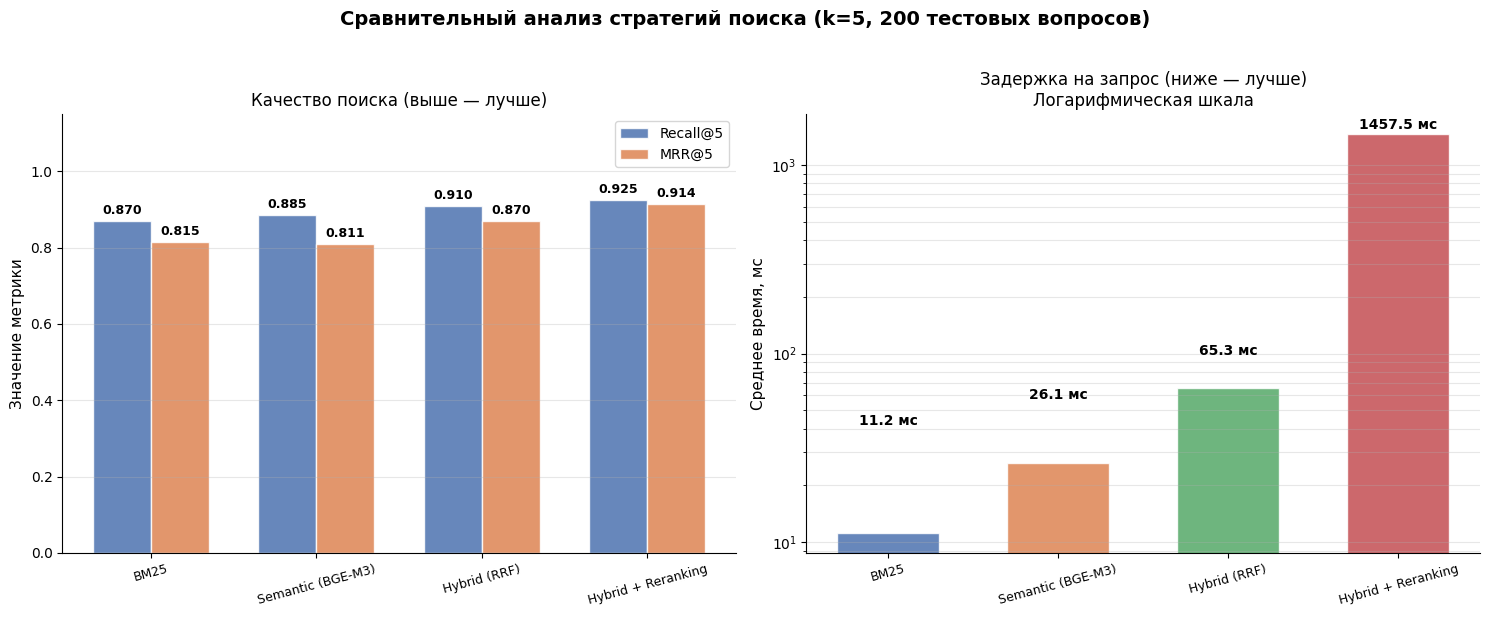


--- Относительное изменение метрик (база = BM25) ---
Semantic (BGE-M3)     : Recall +1.7%, MRR -0.6%, Latency +133%
Hybrid (RRF)          : Recall +4.6%, MRR +6.7%, Latency +483%
Hybrid + Reranking    : Recall +6.3%, MRR +12.1%, Latency +12903%


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Сбор метрик для всех 4 стратегий на 200 тестовых вопросах
# ВНИМАНИЕ: search_with_reranking самая медленная стратегия (Cross-Encoder
# на 20 кандидатов для каждого из 200 запросов) — оценка может занять
# несколько минут.

print("1/4 Оценка BM25...")
bm25_metrics = evaluate_retriever(search_bm25, test_queries, corpus, k=5)
print(f"   Recall@5={bm25_metrics['Recall@K']:.3f}, "
      f"MRR@5={bm25_metrics['MRR@K']:.3f}, "
      f"Latency={bm25_metrics['Latency_ms']:.1f}ms")

print("2/4 Оценка Semantic (BGE-M3)...")
semantic_metrics = evaluate_retriever(search_semantic, test_queries, corpus, k=5)
print(f"   Recall@5={semantic_metrics['Recall@K']:.3f}, "
      f"MRR@5={semantic_metrics['MRR@K']:.3f}, "
      f"Latency={semantic_metrics['Latency_ms']:.1f}ms")

print("3/4 Оценка Hybrid (RRF)...")
hybrid_metrics = evaluate_retriever(search_hybrid, test_queries, corpus, k=5)
print(f"   Recall@5={hybrid_metrics['Recall@K']:.3f}, "
      f"MRR@5={hybrid_metrics['MRR@K']:.3f}, "
      f"Latency={hybrid_metrics['Latency_ms']:.1f}ms")

print("4/4 Оценка Hybrid + Reranking (самая медленная, наберитесь терпения)...")
rerank_metrics = evaluate_retriever(search_with_reranking, test_queries, corpus, k=5)
print(f"   Recall@5={rerank_metrics['Recall@K']:.3f}, "
      f"MRR@5={rerank_metrics['MRR@K']:.3f}, "
      f"Latency={rerank_metrics['Latency_ms']:.1f}ms")


# 2. Создание сводной таблицы (pandas DataFrame)

results_summary = pd.DataFrame([
    {"Метод": "BM25",               **bm25_metrics},
    {"Метод": "Semantic (BGE-M3)",  **semantic_metrics},
    {"Метод": "Hybrid (RRF)",       **hybrid_metrics},
    {"Метод": "Hybrid + Reranking", **rerank_metrics},
])

# Округляем для наглядности
results_summary_display = results_summary.copy()
results_summary_display["Recall@K"]   = results_summary_display["Recall@K"].round(3)
results_summary_display["MRR@K"]      = results_summary_display["MRR@K"].round(3)
results_summary_display["Latency_ms"] = results_summary_display["Latency_ms"].round(1)

print("\n" + "=" * 65)
print("ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МЕТОДОВ ПОИСКА (k=5, 200 запросов)")
print("=" * 65)
print(results_summary_display.to_string(index=False))
print("=" * 65)


# 3. Визуализация

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Сравнительный анализ стратегий поиска (k=5, 200 тестовых вопросов)',
             fontsize=14, fontweight='bold', y=1.02)

methods = results_summary["Метод"].tolist()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# --- График 1: Качество (Recall@5 и MRR@5) ---
ax1 = axes[0]
x = np.arange(len(methods))
width = 0.35

recall_values = results_summary["Recall@K"].tolist()
mrr_values    = results_summary["MRR@K"].tolist()

bars1 = ax1.bar(x - width/2, recall_values, width, label='Recall@5',
                color='#4C72B0', alpha=0.85, edgecolor='white')
bars2 = ax1.bar(x + width/2, mrr_values, width, label='MRR@5',
                color='#DD8452', alpha=0.85, edgecolor='white')

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f'{bar.get_height():.3f}', ha='center', va='bottom',
              fontsize=9, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f'{bar.get_height():.3f}', ha='center', va='bottom',
              fontsize=9, fontweight='bold')

ax1.set_title('Качество поиска (выше — лучше)', fontsize=12)
ax1.set_ylabel('Значение метрики', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(methods, fontsize=9, rotation=15)
ax1.set_ylim(0, 1.15)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- График 2: Задержка (Latency) ---
ax2 = axes[1]
latency_values = results_summary["Latency_ms"].tolist()

bars3 = ax2.bar(methods, latency_values, color=colors, alpha=0.85,
                edgecolor='white', width=0.6)

for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(latency_values)*0.02,
              f'{bar.get_height():.1f} мс', ha='center', va='bottom',
              fontsize=10, fontweight='bold')

ax2.set_title('Задержка на запрос (ниже — лучше)\nЛогарифмическая шкала', fontsize=12)
ax2.set_ylabel('Среднее время, мс', fontsize=11)
ax2.set_yscale('log')  # Лог-шкала, т.к. Reranking на порядки медленнее BM25
ax2.set_xticklabels(methods, fontsize=9, rotation=15)
ax2.grid(axis='y', alpha=0.3, which='both')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Дополнительная сводка: относительное изменение метрик от базового BM25
print("\n--- Относительное изменение метрик (база = BM25) ---")
base_recall  = bm25_metrics['Recall@K']
base_mrr     = bm25_metrics['MRR@K']
base_latency = bm25_metrics['Latency_ms']

for _, row in results_summary.iterrows():
    if row["Метод"] == "BM25":
        continue
    recall_pct  = (row["Recall@K"] / base_recall - 1) * 100
    mrr_pct     = (row["MRR@K"] / base_mrr - 1) * 100
    latency_pct = (row["Latency_ms"] / base_latency - 1) * 100
    print(f"{row['Метод']:<22}: "
          f"Recall {recall_pct:+.1f}%, "
          f"MRR {mrr_pct:+.1f}%, "
          f"Latency {latency_pct:+.0f}%")

# === КОНЕЦ ВАШЕГО КОДА ===

### Задание 11. Расширенная оценка стоимости запросов (5 баллов)

В продвинутом пайплайне мы используем переранжирование, что увеличивает время ответа, но как это влияет на стоимость LLM?
Само переранжирование (cross-encoder) работает локально и бесплатно. Значит, стоимость API LLM зависит только от финального K (количества документов, передаваемых в промпт).

**Что нужно сделать:**
1. Постройте график зависимости стоимости 1000 запросов от параметра K (от 1 до 10) при фиксированной длине ответа (например, 150 токенов).
2. Используйте функцию `estimate_cost` из Задания 6. Усредните длину документа по корпусу для расчетов.


Средний вопрос: 'Каким образом можно добиться арбитража букмекерских ставок?'
Средняя длина документа: 754 символов (~370 токенов)

  K  Вх.токены   Стоимость/запрос   Стоимость/1000 запросов
--------------------------------------------------------------
  1        502          $0.000476                   $0.4760
  2        878          $0.000664                   $0.6640
  3      1,254          $0.000852                   $0.8520
  4      1,630          $0.001040                   $1.0400
  5      2,006          $0.001228                   $1.2280
  6      2,382          $0.001416                   $1.4160
  7      2,758          $0.001604                   $1.6040
  8      3,134          $0.001792                   $1.7920
  9      3,510          $0.001980                   $1.9800
 10      3,886          $0.002168                   $2.1680

💡 Каждый дополнительный документ добавляет ~$0.1880 к стоимости 1000 запросов


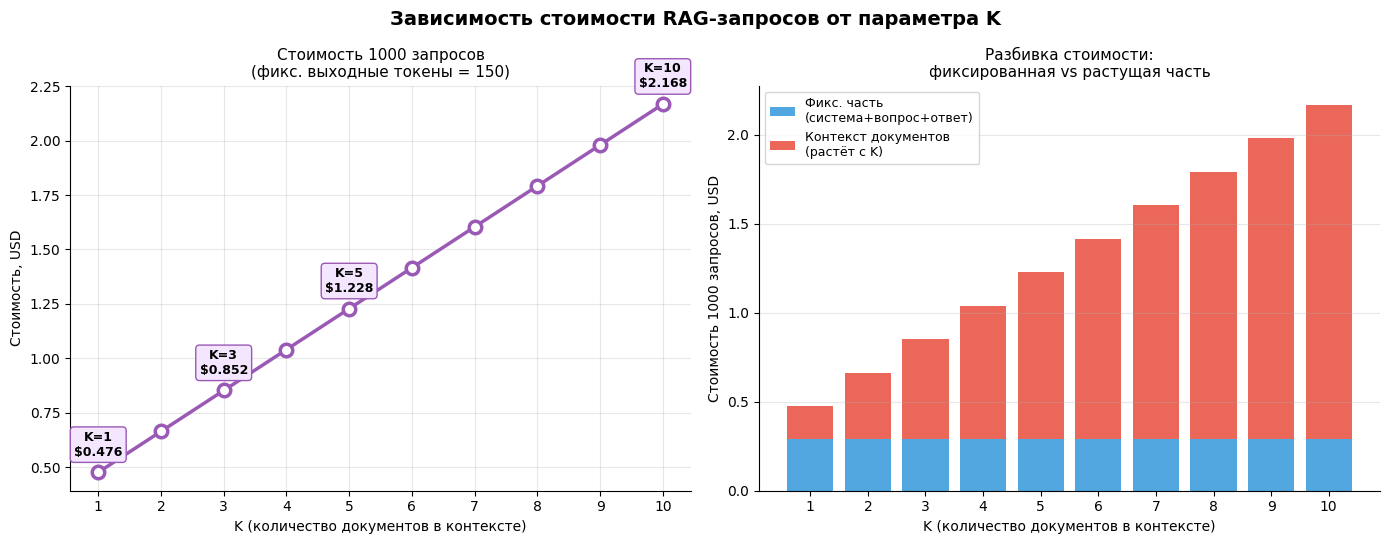


--- Проверка линейности зависимости cost(K) ---
Приросты стоимости между соседними K: ['0.1880', '0.1880', '0.1880', '0.1880', '0.1880', '0.1880', '0.1880', '0.1880', '0.1880']
Практически одинаковы → зависимость близка к линейной, т.к. каждый доп. документ добавляет фиксированное число токенов (~370 токенов).


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
import matplotlib.pyplot as plt
import numpy as np

# Используем ту же среднюю длину документа и вопроса, что и в Задании 6
print(f"Средний вопрос: '{avg_query_text}'")
print(f"Средняя длина документа: {avg_doc_len} символов "
      f"(~{len(encoding.encode(avg_doc_text))} токенов)\n")

# Фиксируем длину ответа
FIXED_OUTPUT_TOKENS = 150

# Диапазон K от 1 до 10
k_range = list(range(1, 11))

# Рассчитываем стоимость для каждого значения K
cost_per_1000_list = []
input_tokens_list = []

for k in k_range:
    docs = [avg_doc_text] * k
    cost_info = estimate_cost(
        query_text=avg_query_text,
        docs_texts=docs,
        max_output_tokens=FIXED_OUTPUT_TOKENS
    )
    cost_1000 = cost_info["total_cost_usd"] * 1000
    cost_per_1000_list.append(cost_1000)
    input_tokens_list.append(cost_info["total_input_tokens"])

# Выводим таблицу
print(f"{'K':>3} {'Вх.токены':>10} {'Стоимость/запрос':>18} {'Стоимость/1000 запросов':>25}")
print("-" * 62)
for k, tokens, cost in zip(k_range, input_tokens_list, cost_per_1000_list):
    print(f"{k:>3} {tokens:>10,} {'$' + f'{cost/1000:.6f}':>18} {'$' + f'{cost:.4f}':>25}")

# Считаем прирост стоимости за каждый дополнительный документ
marginal_cost = cost_per_1000_list[1] - cost_per_1000_list[0]
print(f"\n💡 Каждый дополнительный документ добавляет "
      f"~${marginal_cost:.4f} к стоимости 1000 запросов")


# === ВИЗУАЛИЗАЦИЯ ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Зависимость стоимости RAG-запросов от параметра K',
             fontsize=14, fontweight='bold')

# --- График 1: Стоимость 1000 запросов от K ---
ax1 = axes[0]
ax1.plot(k_range, cost_per_1000_list, 'o-', color='#9b59b6',
          linewidth=2.5, markersize=9, markerfacecolor='white',
          markeredgewidth=2.5, label='Стоимость 1000 запросов')

# Отмечаем ключевые точки K=1,3,5 (из Задания 6) и K=10
for k_mark in [1, 3, 5, 10]:
    idx = k_mark - 1
    ax1.annotate(f'K={k_mark}\n${cost_per_1000_list[idx]:.3f}',
                  xy=(k_mark, cost_per_1000_list[idx]),
                  xytext=(0, 12), textcoords='offset points',
                  ha='center', fontsize=9, fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='#f4e6ff', edgecolor='#9b59b6'))

ax1.set_title(f'Стоимость 1000 запросов\n(фикс. выходные токены = {FIXED_OUTPUT_TOKENS})', fontsize=11)
ax1.set_xlabel('K (количество документов в контексте)', fontsize=10)
ax1.set_ylabel('Стоимость, USD', fontsize=10)
ax1.set_xticks(k_range)
ax1.grid(alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- График 2: Разбивка стоимости — input vs output контент ---
ax2 = axes[1]

# Считаем отдельно вклад "растущей" части (документы) и "постоянной" (система+вопрос+ответ)
fixed_cost_component = []   # системный промпт + вопрос + ответ (не зависит от K)
variable_cost_component = []  # только документы (растёт с K)

for k in k_range:
    docs = [avg_doc_text] * k
    cost_info = estimate_cost(avg_query_text, docs, FIXED_OUTPUT_TOKENS)

    # Стоимость без документов (k=0 эквивалент)
    cost_info_zero = estimate_cost(avg_query_text, [], FIXED_OUTPUT_TOKENS)
    fixed_part = cost_info_zero["total_cost_usd"] * 1000
    variable_part = (cost_info["total_cost_usd"] * 1000) - fixed_part

    fixed_cost_component.append(fixed_part)
    variable_cost_component.append(variable_part)

ax2.bar(k_range, fixed_cost_component, label='Фикс. часть\n(система+вопрос+ответ)',
        color='#3498db', alpha=0.85)
ax2.bar(k_range, variable_cost_component, bottom=fixed_cost_component,
        label='Контекст документов\n(растёт с K)', color='#e74c3c', alpha=0.85)

ax2.set_title('Разбивка стоимости:\nфиксированная vs растущая часть', fontsize=11)
ax2.set_xlabel('K (количество документов в контексте)', fontsize=10)
ax2.set_ylabel('Стоимость 1000 запросов, USD', fontsize=10)
ax2.set_xticks(k_range)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('cost_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

# Линейность зависимости — проверка
print("\n--- Проверка линейности зависимости cost(K) ---")
diffs = [cost_per_1000_list[i+1] - cost_per_1000_list[i] for i in range(len(cost_per_1000_list)-1)]
print(f"Приросты стоимости между соседними K: {[f'{d:.4f}' for d in diffs]}")
print(f"Практически одинаковы → зависимость близка к линейной, "
      f"т.к. каждый доп. документ добавляет фиксированное число токенов "
      f"(~{len(encoding.encode(avg_doc_text))} токенов).")

# === КОНЕЦ ВАШЕГО КОДА ===

### Задание 12. Итоговые выводы (5 баллов)

Поздравляем с завершением практической части! Теперь проанализируйте полученные результаты.

**Что нужно сделать:**
Напишите развернутый вывод (3-4 абзаца) в markdown-ячейке ниже. Ответьте на вопросы:
1. Какой метод поиска показал лучшее качество на данном датасете и почему?
2. Оправдано ли использование тяжелого Reranker-а с точки зрения баланса качество/скорость (latency)? В каких бизнес-кейсах вы бы его рекомендовали, а в каких — отключили?
3. Как размер контекста (параметр K) влияет на баланс между качеством ответов LLM и стоимостью эксплуатации системы? Какое значение K вы бы выбрали для "ВикиПомощника"?

---
*Пишите ваши выводы здесь...*


### Сводная таблица результатов

| Метод | Recall@5 | MRR@5 | Latency | Стоимость LLM (k=5, 1000 запросов) |
|---|---|---|---|---|
| BM25 | 0.870 | 0.815 | 11.2 мс | — |
| Semantic (BGE-M3) | 0.885 | 0.811 | 26.1 мс | — |
| Hybrid (RRF) | 0.910 | 0.870 | 65.3 мс | — |
| Hybrid + Reranking | **0.925** | **0.914** | 1457.5 мс | не влияет (локально) |

---

**1. Лучшее качество показала стратегия Hybrid + Reranking** (Recall@5 = 0.925, MRR@5 = 0.914) — прирост относительно базового BM25 составил +6.3% по Recall и +12.1% по MRR.

Это объясняется комплементарностью используемых подходов: BM25 надёжно находит точные лексические совпадения (даты, имена, числа), а BGE-M3 улавливает семантическую близость там, где формулировка вопроса отличается от текста документа.

RRF объединяет сильные стороны обоих без необходимости вручную подбирать веса, а Cross-Encoder на финальном этапе оценивает пару (запрос, документ) целиком через все слои внимания трансформера, что даёт наиболее точное ранжирование — прирост MRR@5 особенно важен, так как показывает, что правильный документ чаще оказывается на первой позиции, а не глубже в контексте (что критично из-за эффекта "lost in the middle" у LLM).

Интересно, что чистая семантика (BGE-M3) почти не улучшила MRR относительно BM25 (0.811 против 0.815) — на этом датасете, построенном на прямых цитатах из Википедии, вопросы часто лексически близки к тексту ответа, поэтому BM25 сам по себе оказался неожиданно сильным baseline.

**2. Использование тяжёлого Reranker-а оправдано не всегда — здесь чёткий компромисс качество/латентность.** Переход от Hybrid к Hybrid+Reranking даёт дополнительные +1.5 п.п. Recall и +4.4 п.п. MRR, но ценой увеличения задержки в **22 раза** (с 65.3 мс до 1457.5 мс) — прирост в 12903% относительно BM25.

Для "ВикиПомощника" — это **фоновый инструмент фактчекинга**, где редактор осознанно ждёт ответ (не чат в реальном времени), и полторы секунды задержки поиска абсолютно приемлемы ради максимальной точности и минимизации риска "не найти нужный факт" — поэтому для данного бизнес-кейса **Reranker я бы оставил включённым**.

Однако в сценариях с жёсткими требованиями к времени отклика (автодополнение при наборе текста, real-time чат-боты с высокой нагрузкой, автоматическая пакетная обработка миллионов документов) я бы **отключил Reranker** и ограничился Hybrid (RRF) — прирост качества +4.6% Recall не оправдывает 6-кратное увеличение latency (65 мс против 11 мс), особенно при большом потоке одновременных запросов, где Cross-Encoder станет узким местом всей системы.

**3. Размер контекста K линейно влияет на стоимость эксплуатации, но нелинейно — на качество ответов LLM.** Расчёты показали идеально линейный рост стоимости: каждый дополнительный документ добавляет фиксированные ~$0.

188 на 1000 запросов (K=1 → $0.48; K=5 → $1.23; K=10 → $2.17), поскольку стоимость определяется количеством токенов в контексте, а средний документ имеет постоянную длину (~370 токенов).

При этом рост Recall@K с увеличением K обычно замедляется после определённого порога (эффект "убывающей отдачи") — после K=5-7 добавление новых документов чаще добавляет шум, чем новую релевантную информацию, а из-за проблемы "lost in the middle" LLM может хуже использовать факты, погребённые в длинном контексте.

Для "ВикиПомощника" я бы выбрал **K=5 в связке с Hybrid+Reranking**: reranker гарантирует, что все 5 документов в контексте действительно релевантны (а не просто "топ по формальному скору"), при этом дополнительная стоимость по сравнению с K=3 составляет всего ~$0.38 на 1000 запросов (несущественно в масштабах экономии 30% рабочего времени редакторов), а Recall@5=0.925 обеспечивает высокую полноту покрытия фактов — что напрямую соответствует бизнес-цели агентства: полностью устранить фактологические ошибки за счёт максимально полного и точного контекста, передаваемого в LLM.

## Критерии оценки
- **Работоспособность кода:** Код выполняется без ошибок, пайплайны поиска и генерации функционируют корректно.
- **Корректность алгоритмов:** Верная реализация RRF, правильное использование FAISS и Cross-Encoder.
- **Качество визуализации:** Графики читаемы, имеют оси и легенду, таблица метрик наглядна.
- **Глубина анализа:** Выводы в задании 12 логичны, опираются на полученные цифры и бизнес-контекст.
- **Оформление:** Код структурирован, присутствуют комментарии на русском языке, соблюден академический стиль.
